In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.9 MB/s eta 0:00:00


In [2]:
import os
import zipfile
from ultralytics import YOLO
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = "/content/drive/MyDrive"
os.listdir(path)

['نموذج بدون عنوان.gform',
 'Classroom',
 'Section_Algorithms_Tasks_Ahmed_Saleh',
 'Project',
 'words',
 'Untitled spreadsheet (1).gsheet',
 'Untitled spreadsheet.gsheet',
 'Task (OS)',
 'VP',
 'Colab Notebooks',
 'My solution and homework',
 'Screenshot_20250812-162749.jpg',
 'Computer Secuirty Project.gdoc',
 'IMG-20240425-WA0006.jpg',
 'IMG-20240425-WA0005.jpg',
 'IMG-20260408-WA0024.jpg',
 'IMG-20260408-WA0025.jpg',
 'IMG-20260408-WA0022.jpg',
 'IMG-20260408-WA0023.jpg',
 "To ICPC'25 ACPC Seniors Training.gsheet",
 'weapon_dataset.zip']

In [5]:
path_dataset_zip = "/content/drive/MyDrive/weapon_dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(path_dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")

Done


In [7]:
import yaml

def get_dataset_info(yaml_path):
    with open(yaml_path, 'r') as file:
        data = yaml.safe_load(file)
    print("Dataset Configuration (data.yaml):")
    for key, value in data.items():
        print(f"  {key}: {value}")
    return data

data_yaml_path = "/content/dataset/weapon_dataset/data.yaml"

dataset_info = get_dataset_info(data_yaml_path)

Dataset Configuration (data.yaml):
  train: /content/dataset/weapon_dataset/train
  val: /content/dataset/weapon_dataset/valid
  test: /content/dataset/weapon_dataset/test
  nc: 1
  names: ['weapon']


In [8]:
import os

def count_images_in_dataset(dataset_info):
    for key in ['train', 'val', 'test']:
        path = dataset_info[key]
        path = os.path.join(path, 'labels')
        num_images = len([name for name in os.listdir(path) if os.path.isfile(os.path.join(path, name))])
        print(f"Number of images in {key} set: {num_images}")

count_images_in_dataset(dataset_info)

Number of images in train set: 7494
Number of images in val set: 1933
Number of images in test set: 922


In [9]:
class YOLOv8WeaponDetector:
    def __init__(self, model_size="yolov8n.pt", device=None):
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = YOLO(model_size)
        self.model.to(self.device)

    def train(self, data_yaml, epochs=50, imgsz=640, batch=16):
        results = self.model.train(
            data=data_yaml,
            epochs=epochs,
            imgsz=imgsz,
            batch=batch,
            device=self.device,
            name="weapon_detector"
        )
        return results

    def validate(self):
        return self.model.val()

    def predict(self, image_path, conf=0.25):
        results = self.model.predict(source=image_path, conf=conf)
        return results

    def export(self, format="onnx"):
        self.model.export(format=format)

In [10]:
detector_s = YOLOv8WeaponDetector(model_size="yolov8s.pt")

In [11]:
print("Training YOLOv8s model...")
results_s = detector_s.train(data_yaml=data_yaml_path, epochs=100, imgsz=640, batch=32)
print("YOLOv8s training complete.")

Training YOLOv8s model...
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/weapon_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weapon_detector, nbs=64, nms=False, opset=None, optimize=False, op

YOLOv8s Training Results:


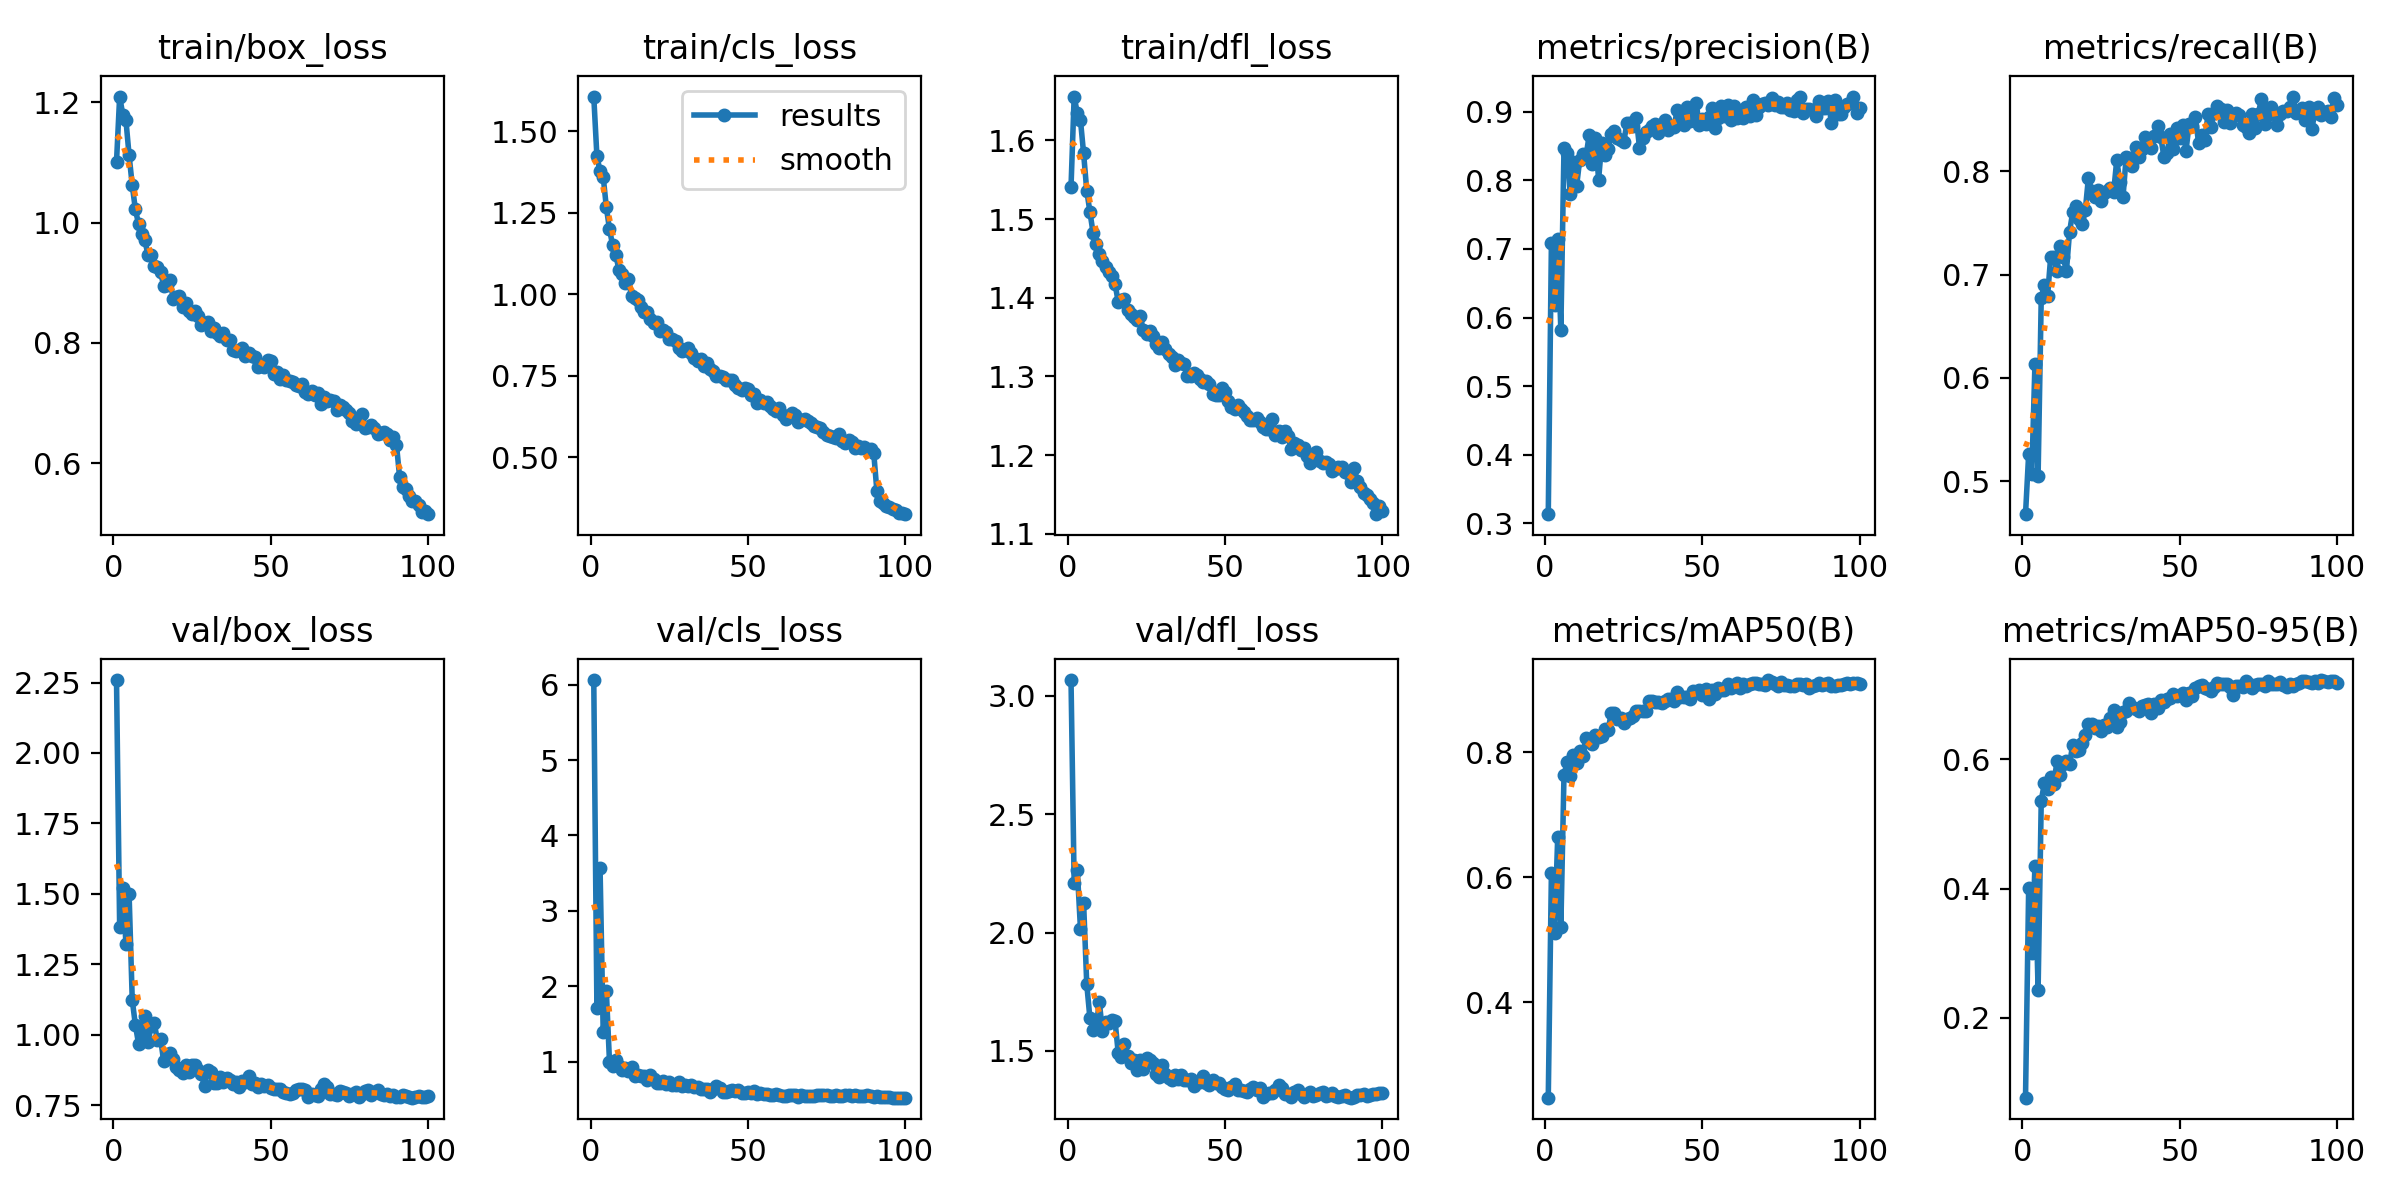

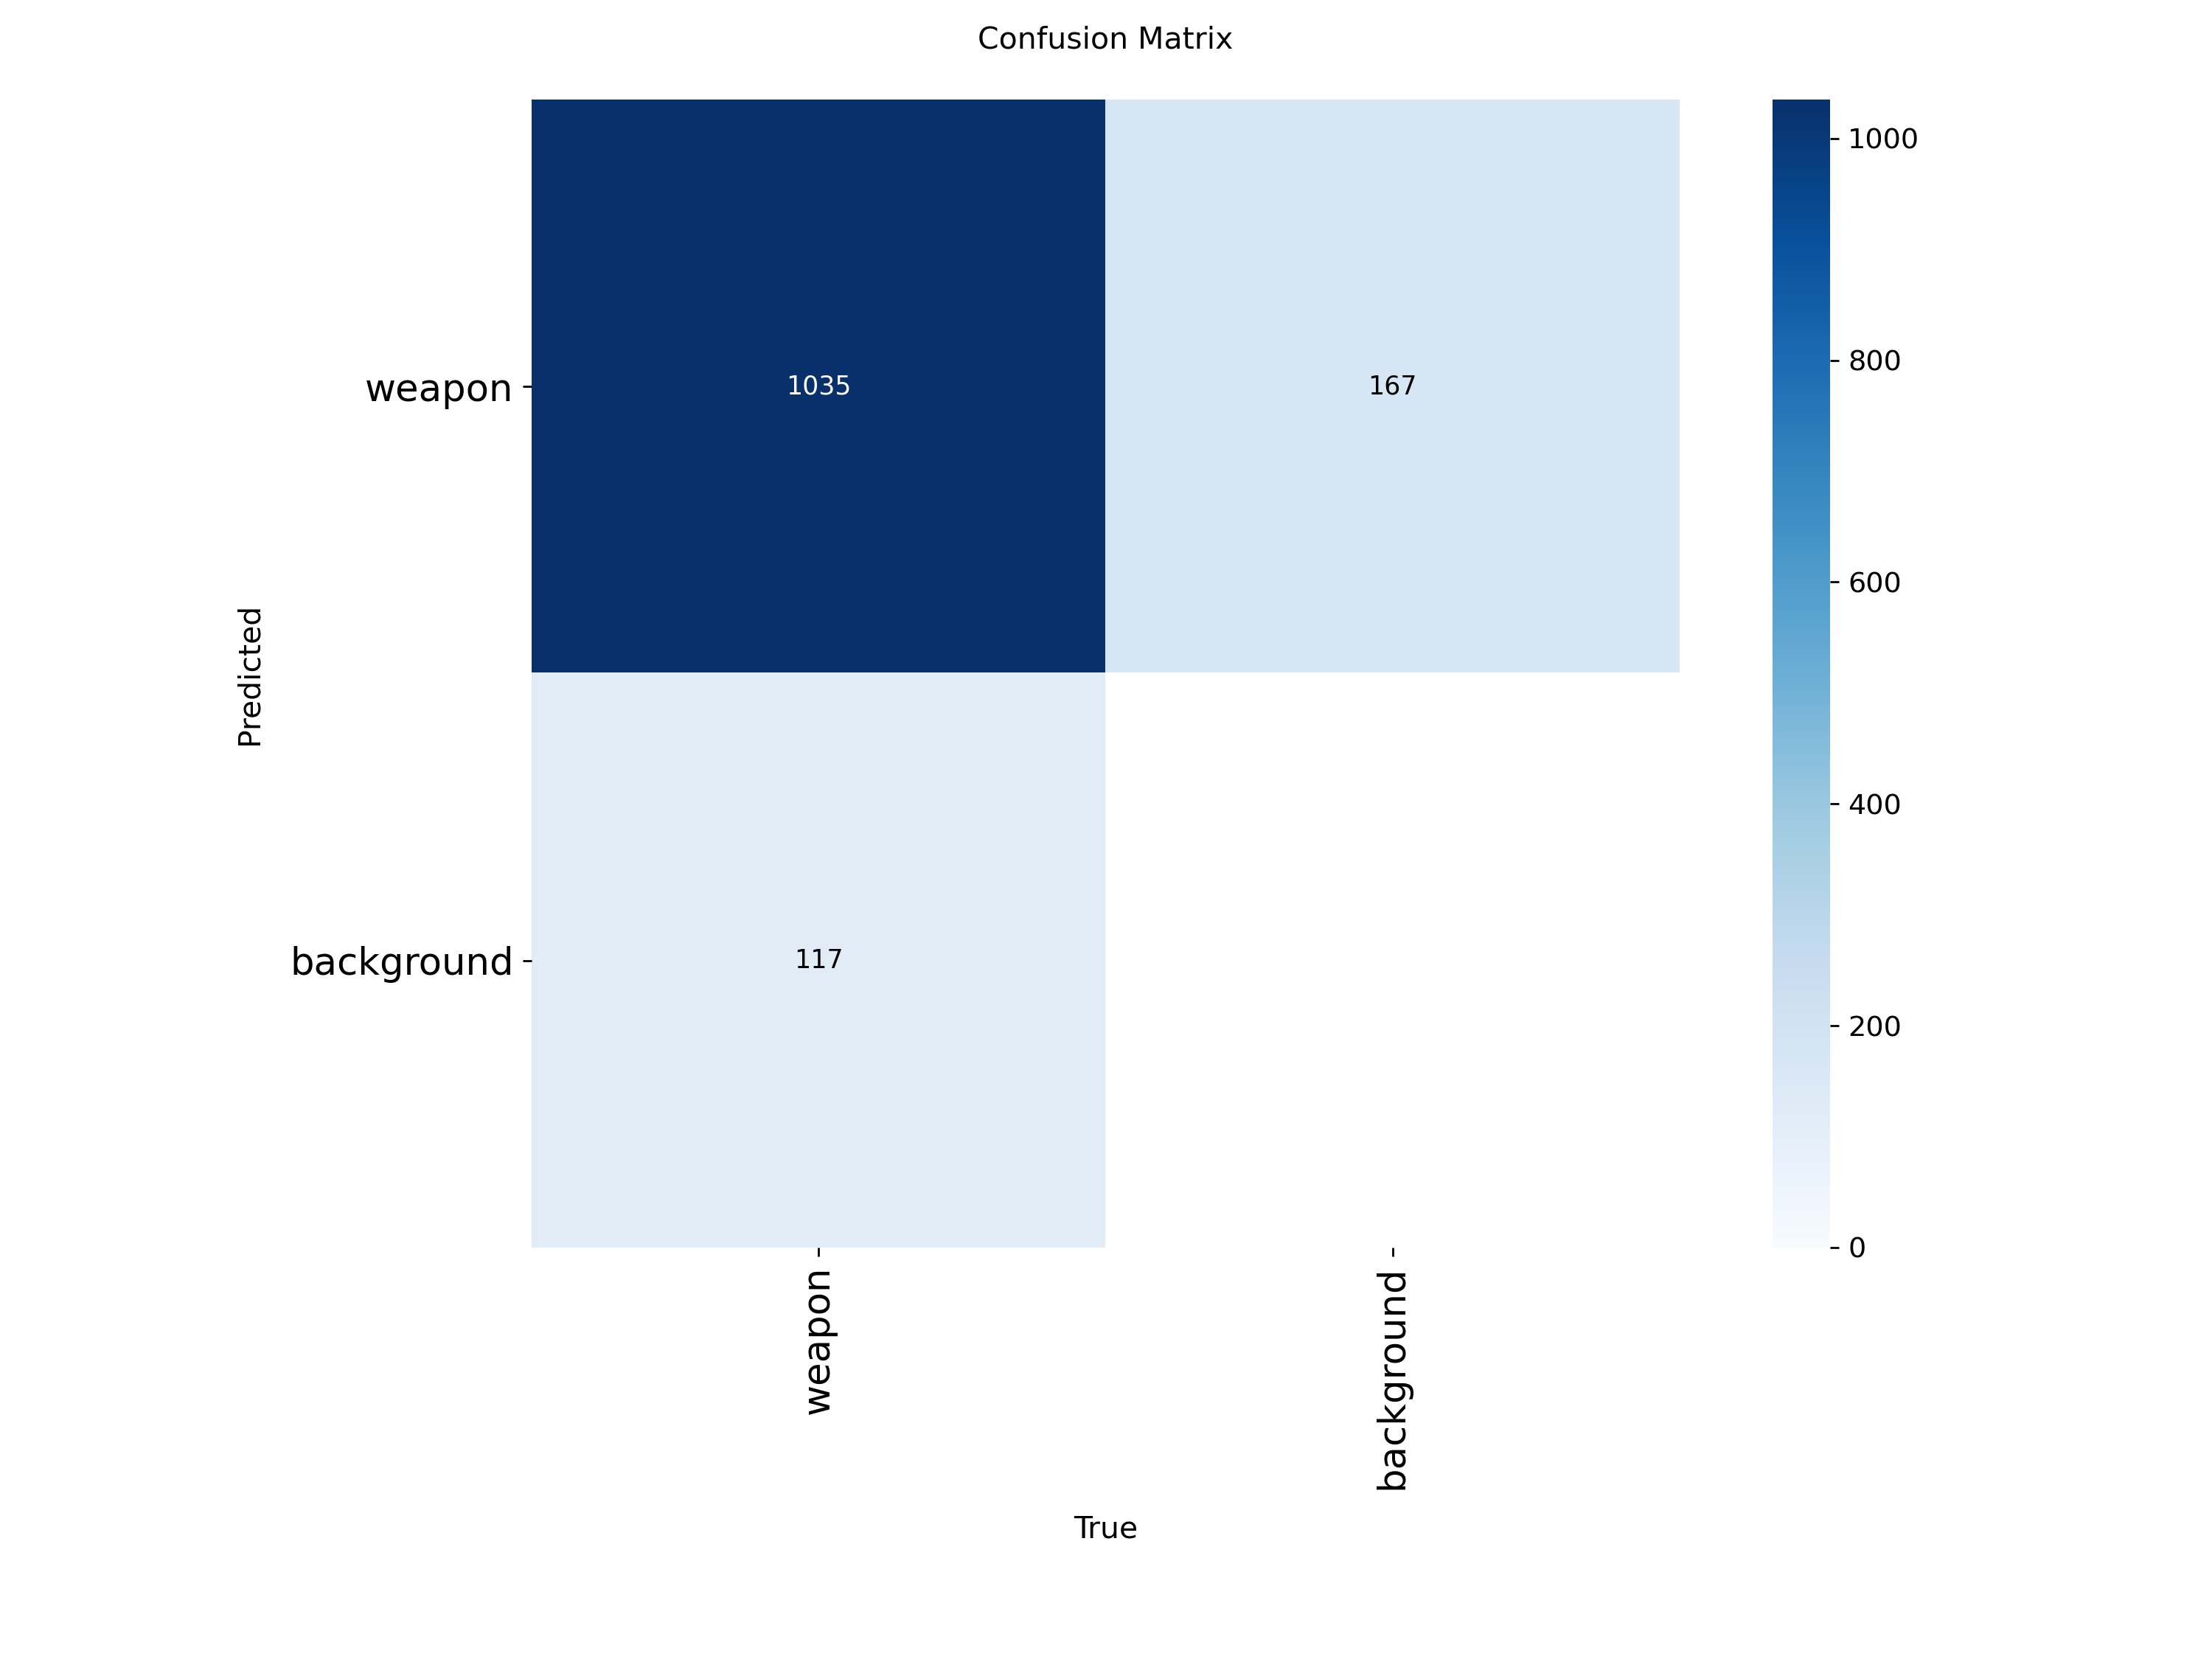

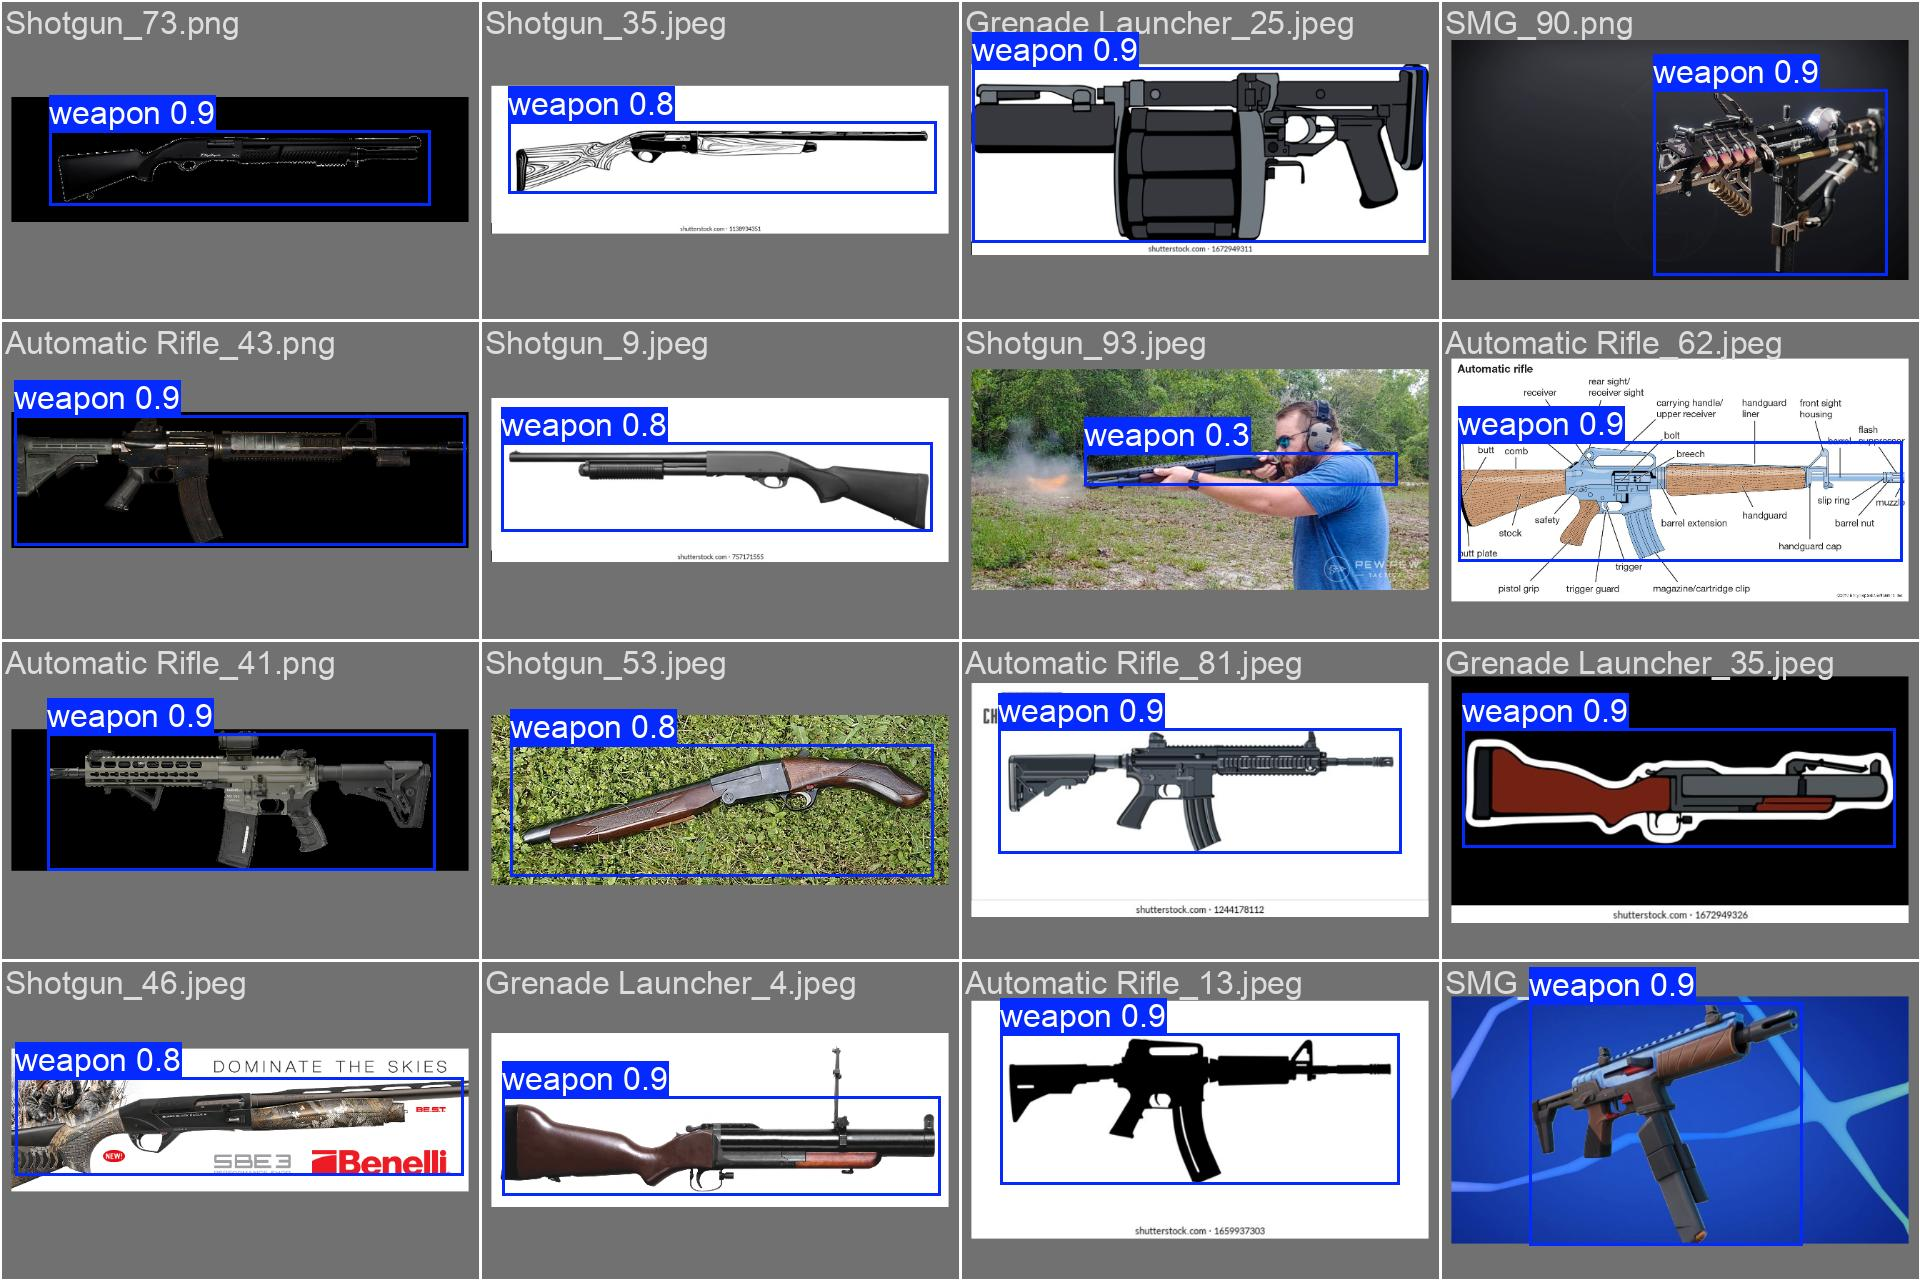

In [13]:

from IPython.display import Image, display
print("YOLOv8s Training Results:")
display(Image(filename=os.path.join(results_s.save_dir, 'results.png')))
display(Image(filename=os.path.join(results_s.save_dir, 'confusion_matrix.png')))
display(Image(filename=os.path.join(results_s.save_dir, 'val_batch0_pred.jpg')))

In [14]:
print("Exporting YOLOv8s model...")
detector_s.export(format="onnx")
print("YOLOv8s model exported.")

Exporting YOLOv8s model...
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/runs/detect/weapon_detector/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 331ms
Prepared 4 packages in 5.99s
Installed 4 packages in 327ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 7.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export w

In [18]:
from google.colab import files
files.download(os.path.join(results_s.save_dir, 'weights', 'best.onnx'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
from google.colab import files
import os

image_files = ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg']
print("Downloading YOLOv8s result images...")
for img_file in image_files:
    file_path = os.path.join(results_s.save_dir, img_file)
    if os.path.exists(file_path):
        files.download(file_path)
    else:
        print(f"Warning: {img_file} not found for YOLOv8s at {file_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>